In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [2]:
file = "Latihan UV Vis 21 Juli 2022.xlsx"

df = pd.read_excel(file)

print("Ukuran Awal :", df.shape)

df.head()

Ukuran Awal : (5, 186)


,No.,Type,Name,Date/Time,Note,200,205,210,215,220,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,1,Sample,UV 1264,2022-07-20 15:02:00,NaN,4.8830,4.6093,4.3077,3.9963,3.6904,...,0.2748,0.2741,0.2733,0.2726,0.2719,0.2711,0.2702,0.2692,0.2681,0.2669
1,2,Sample,UV 1265,2022-07-20 15:13:00,NaN,6.0962,5.5991,5.0360,4.4370,3.8294,...,0.1760,0.1747,0.1733,0.1721,0.1708,0.1695,0.1683,0.1670,0.1657,0.1644
2,3,Sample,UV 1266,2022-07-20 15:11:00,NaN,5.2437,5.1079,4.9146,4.6848,4.4369,...,0.1762,0.1748,0.1735,0.1722,0.1709,0.1697,0.1685,0.1673,0.1661,0.1649
3,4,Sample,UV 1267,2022-07-20 15:19:00,NaN,1.4835,1.4050,1.3324,1.2672,1.2108,...,0.1498,0.1481,0.1465,0.1450,0.1434,0.1420,0.1405,0.1392,0.1378,0.1365
4,5,Sample,UV 1268,2022-07-20 15:22:00,NaN,0.8686,1.0941,1.2534,1.3570,1.4148,...,0.3507,0.3501,0.3495,0.3489,0.3483,0.3476,0.3469,0.3461,0.3452,0.3442


In [3]:
drop_cols = [
    'No.',
    'Type',
    'Date/Time',
    'Note'
]

for col in drop_cols:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

print("Ukuran Setelah Cleaning :", df.shape)

df.head()

Ukuran Setelah Cleaning : (5, 182)


,Name,200,205,210,215,220,225,230,235,240,...,1055,1060,1065,1070,1075,1080,1085,1090,1095,1100
0,UV 1264,4.8830,4.6093,4.3077,3.9963,3.6904,3.4028,3.1441,2.9223,2.7428,...,0.2748,0.2741,0.2733,0.2726,0.2719,0.2711,0.2702,0.2692,0.2681,0.2669
1,UV 1265,6.0962,5.5991,5.0360,4.4370,3.8294,3.2368,2.6797,2.1752,1.7371,...,0.1760,0.1747,0.1733,0.1721,0.1708,0.1695,0.1683,0.1670,0.1657,0.1644
2,UV 1266,5.2437,5.1079,4.9146,4.6848,4.4369,4.1872,3.9494,3.7349,3.5529,...,0.1762,0.1748,0.1735,0.1722,0.1709,0.1697,0.1685,0.1673,0.1661,0.1649
3,UV 1267,1.4835,1.4050,1.3324,1.2672,1.2108,1.1642,1.1279,1.1021,1.0870,...,0.1498,0.1481,0.1465,0.1450,0.1434,0.1420,0.1405,0.1392,0.1378,0.1365
4,UV 1268,0.8686,1.0941,1.2534,1.3570,1.4148,1.4359,1.4285,1.4000,1.3570,...,0.3507,0.3501,0.3495,0.3489,0.3483,0.3476,0.3469,0.3461,0.3452,0.3442


In [4]:
sample_1264 = df.iloc[0,1:].values.astype(float)
sample_1265 = df.iloc[1,1:].values.astype(float)
sample_1266 = df.iloc[2,1:].values.astype(float)
sample_1267 = df.iloc[3,1:].values.astype(float)
sample_1268 = df.iloc[4,1:].values.astype(float)

wavelength = df.columns[1:].astype(float)

In [5]:
def evaluate_model(model_name,
                   y_test,
                   pred_test):

    r2 = r2_score(
        y_test,
        pred_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred_test
        )
    )

    print(f"\n=== {model_name} ===")
    print("R² :", r2)
    print("RMSE :", rmse)

    return [
        model_name,
        r2,
        rmse
    ]

In [ ]:
def run_scenario(
        X,
        y,
        wavelength,
        scenario_name,
        test_size=0.3,
        show_plot=True):

    split_label = f"{int((1-test_size)*100)}:{int(test_size*100)}"

    print("\n")
    print("="*60)
    print(f"{scenario_name} | Split {split_label}")
    print("="*60)

    print("Shape X :", X.shape)
    print("Shape y :", y.shape)

    # Split data sesuai rasio test_size

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        shuffle=True,
        random_state=42
    )

    wave_train, wave_test = train_test_split(
        wavelength,
        test_size=test_size,
        shuffle=True
    )

    # StandardScaler

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    results = []

    # ====================================
    # Visualisasi
    # ====================================
    print("Masuk ke visualisasi")
    def plot_result(
        wavelength_test,
        y_test,
        y_pred,
        model_name,
        scenario_name,
        split_label):

        plt.figure(figsize=(12,6))

        plt.plot(
            wavelength,
            y,
            label='Aktual',
            linewidth=3
        )

        plt.plot(
            wavelength,
            pred_linear_full,
            '--',
            label='Prediksi Linear'
        )

        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Absorbance')

        plt.title(
            f'{scenario_name} - Linear Regression'
        )

        plt.legend()
        plt.grid(True)

        plt.show()

        plt.figure(figsize=(12,6))

        plt.plot(
            wavelength,
            y,
            label='Aktual',
            linewidth=3
        )

        plt.plot(
            wavelength,
            pred_poly_full,
            '--',
            label='Prediksi Polynomial'
        )

        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Absorbance')

        plt.title(
            f'{scenario_name} - Polynomial Regression'
        )

        plt.legend()
        plt.grid(True)
        plt.show()
        
        # plt.figure(figsize=(12,6))

        # plt.plot(
        #     wavelength_test,
        #     y_test,
        #     label='Actual',
        #     linewidth=3
        # )

        # plt.plot(
        #     wavelength_test,
        #     y_pred, 
        #     label='Prediction',
        #     linestyle='--'
        # )

        # plt.title(
        #     f'{scenario_name}\n{model_name} | Split {split_label}'
        # )

        # plt.xlabel('Data Testing')
        # plt.ylabel('Absorbance')

        # plt.legend()
        # plt.grid(True)

        # plt.show()

    # ====================================
    # Linear Regression
    # ====================================

    linear = LinearRegression()

    linear.fit(
        X_train_scaled,
        y_train
    )

    pred_linear = linear.predict(
        X_test_scaled
    )
    # Prediksi seluruh wavelength
    X_full_scaled = scaler.transform(X)

    pred_linear_full = linear.predict(
        X_full_scaled
    )
    if show_plot:
        plot_result(
            wave_test,
            y_test,
            pred_linear,
            "Linear Regression",
            scenario_name,
            split_label
        )
    results.append(

        evaluate_model(
            "Linear Regression",
            y_test,
            pred_linear
        )

    )

    # ====================================
    # Polynomial Regression
    # ====================================

    poly = Pipeline([

        (
            'poly',
            PolynomialFeatures(
                degree=2,
                include_bias=False
            )
        ),

        (
            'linear',
            LinearRegression()
        )

    ])

    poly.fit(
        X_train_scaled,
        y_train
    )

    pred_poly = poly.predict(
        X_test_scaled
    )
    # Prediksi seluruh wavelength
    X_full_scaled = scaler.transform(X)

    pred_poly_full = poly.predict(
        X_full_scaled
    )
    if show_plot:

        plot_result(
            wave_test,
            y_test,
            pred_poly,
            "Polynomial Regression",
            scenario_name,
            split_label
        )

    results.append(

        evaluate_model(
            "Polynomial Regression",
            y_test,
            pred_poly
        )

    )

    # ====================================
    # Random Forest
    # ====================================

    rf = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    rf.fit(
        X_train_scaled,
        y_train
    )

    pred_rf = rf.predict(
        X_test_scaled
    )
    # Prediksi seluruh wavelength
    X_full_scaled = scaler.transform(X)

    pred_rf_full = rf.predict(
        X_full_scaled
    )
    if show_plot:

        plot_result(
            wave_test,
            y_test,
            pred_rf,
            "Random Forest",
            scenario_name,
            split_label
        )
        
    results.append(

        evaluate_model(
            "Random Forest",
            y_test,
            pred_rf
        )

    )

    # ====================================
    # Tabel Hasil
    # ====================================

    hasil = pd.DataFrame(

        results,

        columns=[
            "Model",
            "R2",
            "RMSE"
        ]

    )
    hasil.insert(0, "Split", split_label)
    hasil.insert(0, "Scenario", scenario_name)

    print("\n")
    print(hasil)

    return hasil



SKENARIO 1 : (1264,1265,1266) -> 1267 | Split 60:40
Shape X : (181, 3)
Shape y : (181,)
Masuk ke visualisasi


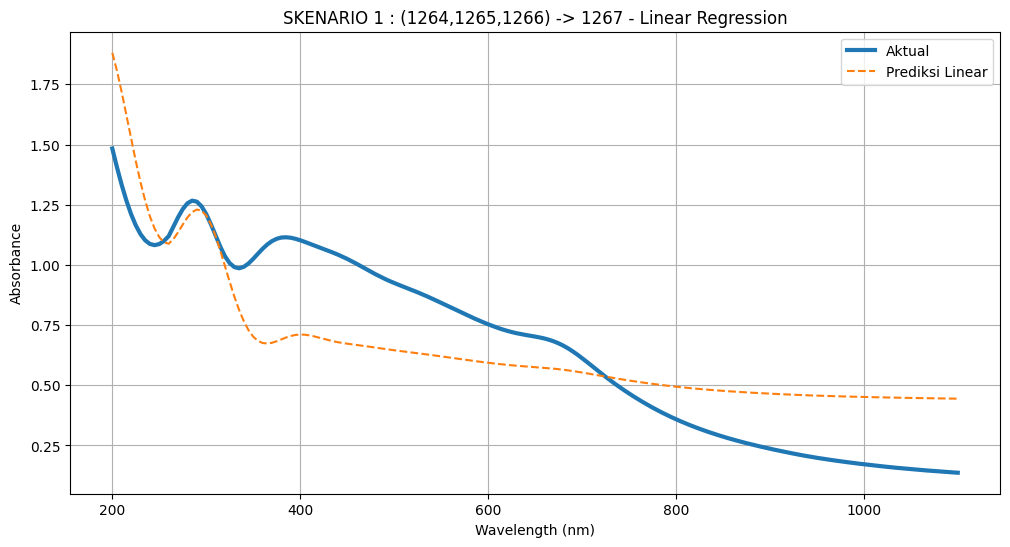

NameError: cannot access free variable 'pred_poly_full' where it is not associated with a value in enclosing scope

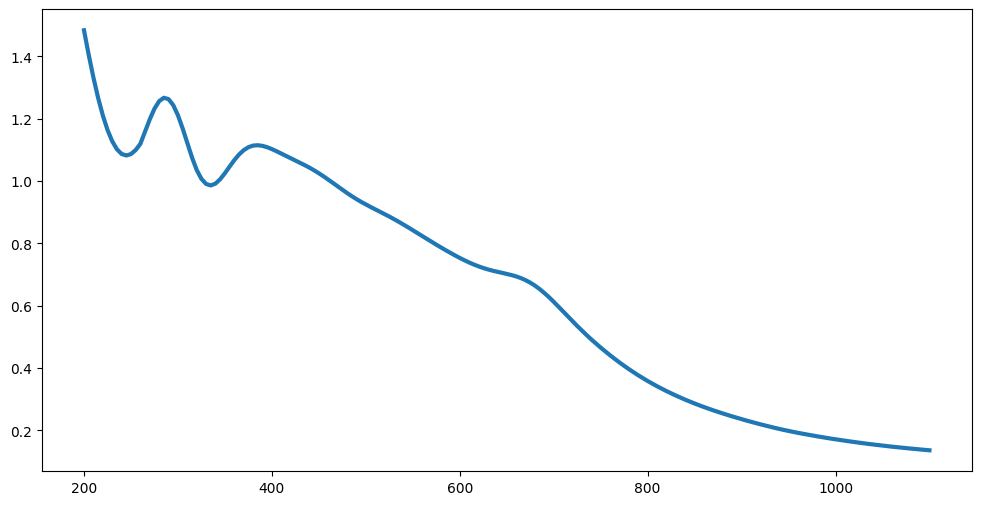

In [15]:
X1 = np.column_stack([

    sample_1264,
    sample_1265,
    sample_1266

])

y1 = sample_1267

split_list = [0.4, 0.3, 0.2, 0.1]

hasil_s1_all = []

for ts in split_list:
    hasil_tmp = run_scenario(
        X1,
        y1,
        wavelength,
        "SKENARIO 1 : (1264,1265,1266) -> 1267",
        test_size=ts,
        show_plot=True
    )
    hasil_s1_all.append(hasil_tmp)

hasil_s1_compare = pd.concat(hasil_s1_all, ignore_index=True)

print("\nPerbandingan Split - Skenario 1")
display(hasil_s1_compare.sort_values(["Split", "Model"]).reset_index(drop=True))

In [8]:
X2 = np.column_stack([

    sample_1264,
    sample_1265,
    sample_1266,
    sample_1267

])

y2 = sample_1268

split_list = [0.4, 0.3, 0.2, 0.1]

hasil_s2_all = []

for ts in split_list:
    hasil_tmp = run_scenario(
        X2,
        y2,
        wavelength,
        "SKENARIO 2 : (1264,1265,1266,1267) -> 1268",
        test_size=ts,
        show_plot=False
    )
    hasil_s2_all.append(hasil_tmp)

hasil_s2_compare = pd.concat(hasil_s2_all, ignore_index=True)

print("\nPerbandingan Split - Skenario 2")
display(hasil_s2_compare.sort_values(["Split", "Model"]).reset_index(drop=True))



SKENARIO 2 : (1264,1265,1266,1267) -> 1268 | Split 60:40
Shape X : (181, 4)
Shape y : (181,)
Masuk ke visualisasi

=== Linear Regression ===
R² : 0.9248942043389365
RMSE : 0.08739672966352048

=== Polynomial Regression ===
R² : 0.9997054636816864
RMSE : 0.005473030686105586

=== Random Forest ===
R² : 0.9816571657881633
RMSE : 0.04319084259312504


                                     Scenario  Split                  Model  \
0  SKENARIO 2 : (1264,1265,1266,1267) -> 1268  60:40      Linear Regression   
1  SKENARIO 2 : (1264,1265,1266,1267) -> 1268  60:40  Polynomial Regression   
2  SKENARIO 2 : (1264,1265,1266,1267) -> 1268  60:40          Random Forest   

         R2      RMSE  
0  0.924894  0.087397  
1  0.999705  0.005473  
2  0.981657  0.043191  


SKENARIO 2 : (1264,1265,1266,1267) -> 1268 | Split 70:30
Shape X : (181, 4)
Shape y : (181,)
Masuk ke visualisasi

=== Linear Regression ===
R² : 0.9206856797883001
RMSE : 0.08955560621048214

=== Polynomial Regression ===
R² : 0.99

,Scenario,Split,Model,R2,RMSE
0,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",60:40,Linear Regression,0.924894,0.087397
1,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",60:40,Polynomial Regression,0.999705,0.005473
2,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",60:40,Random Forest,0.981657,0.043191
3,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",70:30,Linear Regression,0.920686,0.089556
4,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",70:30,Polynomial Regression,0.999646,0.005980
5,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",70:30,Random Forest,0.985096,0.038821
6,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",80:20,Linear Regression,0.888050,0.101180
7,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",80:20,Polynomial Regression,0.999719,0.005065
8,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",80:20,Random Forest,0.980964,0.041723
9,"SKENARIO 2 : (1264,1265,1266,1267) -> 1268",90:10,Linear Regression,0.852586,0.109769


## Kesimpulan Hasil Prediksi Kedua Skenario

1. Secara umum, **Skenario 2** (prediksi 1268 dari 1264, 1265, 1266, 1267) memberikan performa lebih baik daripada **Skenario 1** (prediksi 1267 dari 1264, 1265, 1266), terutama pada model Linear dan Random Forest.

2. Pada **Skenario 1**, model terbaik adalah **Polynomial Regression** dengan rentang nilai **R² = 0.99863 - 0.99928** dan **RMSE = 0.01020 - 0.01445**. Model ini konsisten paling akurat di semua rasio split.

3. Pada **Skenario 2**, model terbaik juga **Polynomial Regression** dengan performa lebih tinggi dan sangat stabil, yaitu **R² = 0.99965 - 0.99972** dan **RMSE = 0.00507 - 0.00598**.

4. Dibandingkan model lain, **Linear Regression** menunjukkan peningkatan besar dari Skenario 1 ke Skenario 2 (R² naik dari sekitar 0.62-0.68 menjadi 0.85-0.92), menandakan tambahan sampel input meningkatkan kemampuan prediksi.

5. **Random Forest** juga membaik pada Skenario 2 (R² sekitar 0.96-0.99) dibanding Skenario 1 (R² sekitar 0.99 tetapi cenderung turun saat split 90:10), namun tetap berada di bawah Polynomial Regression dalam kestabilan error.

6. Dari sisi rasio split, pola terbaik cenderung muncul pada **split 60:40 sampai 80:20**. Split **90:10** menunjukkan kecenderungan penurunan pada beberapa model (terutama Linear dan Random Forest), kemungkinan karena data uji terlalu sedikit sehingga evaluasi kurang representatif.

### Ringkasan Akhir

- **Model paling direkomendasikan:** Polynomial Regression.
- **Skenario paling direkomendasikan:** Skenario 2.
- **Alasan utama:** nilai R² paling mendekati 1 dan RMSE paling kecil serta paling stabil di berbagai split.

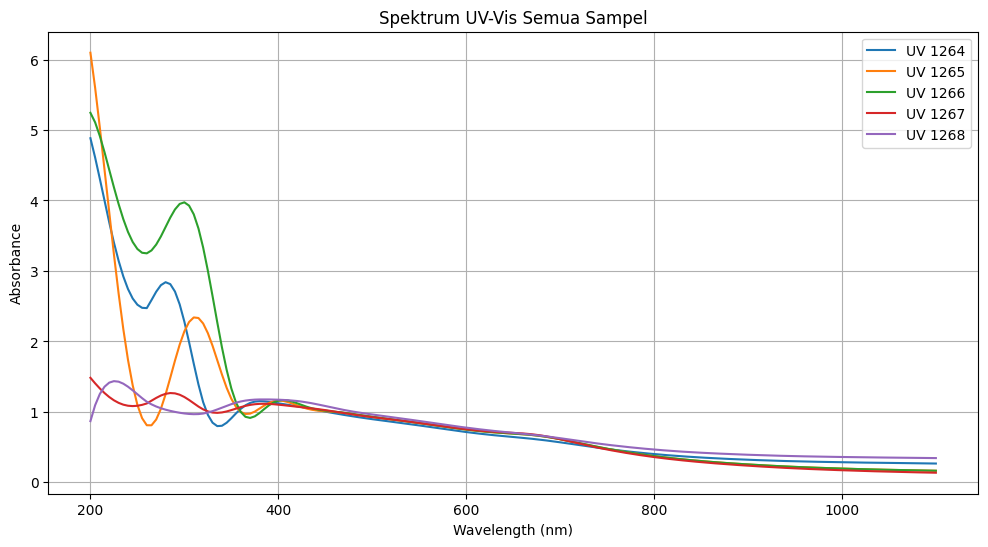

In [9]:
plt.figure(figsize=(12,6))

for i in range(len(df)):
    plt.plot(
        wavelength,
        df.iloc[i,1:].values.astype(float),
        label=df.iloc[i,0]
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.title("Spektrum UV-Vis Semua Sampel")
plt.legend()
plt.grid(True)
plt.show()